## GWR/MGWR example
***
This is a notebook to demsortate how to fit a GWR/MGWR model on an emprical dataset. The mgwr package is developed by Oshan et al. (2019), and it is hosted at https://github.com/pysal/mgwr.

It can be installed by

`!pip install mgwr` in the cell.

***



In [1]:
#!pip install mgwr

### Datasets

We will be working on an example dataset of Georgia counties, and here are some variables in the data.

**TotPop90** Population of the county in 1990

**PctRural** Percentage of the county population defined as rural

**PctBach** Percentage of the county population with a bachelor’s degree 

**PctEld** Percentage of the county population aged 65 or over

**PctFB** Percentage of the county population born outside the US 

**PctPov** Percentage of the county population living below the poverty line 

**PctBlack** Percentage of the county population who are black  


***
We will model the county-level educational attainment with several socio-demographic variables.  

***
The model is:  

PctBach = b0 + b1 * PctFB + b2 * PctBlack + b3 * PctRural




### Load packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import statsmodels.api as sm

#imports for mgwr
from mgwr.gwr import GWR,MGWR
from mgwr.sel_bw import Sel_BW



### Load Georgia dataset from github

In [3]:
georgia_shp = gpd.read_file("https://raw.githubusercontent.com/Ziqi-Li/GIS5106/refs/heads/main/data/Georgia.geojson")

In [4]:
#georgia_shp.set_crs(epsg=32617, inplace=True, allow_override=True)

#georgia_shp.to_file("Georgia.geojson")

The map of Georgia and the centorid of each county.

<Axes: >

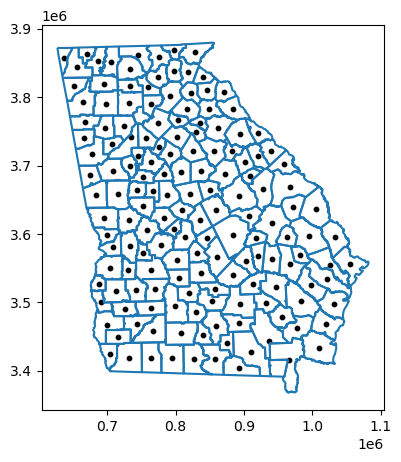

In [5]:
fig, ax = plt.subplots(figsize=(5,5))

georgia_shp.boundary.plot(ax=ax)

georgia_shp.centroid.plot(ax=ax, c='black',markersize = 10)

A map of Georgia for reference 
(source:https://www.enchantedlearning.com/usa/states/georgia/map.GIF)


<img src=https://www.enchantedlearning.com/usa/states/georgia/map.GIF width="200" align="left">

We could map the dependent variable "PctBach".

Text(0.5, 1.0, '% People with a bachelor’s degree')

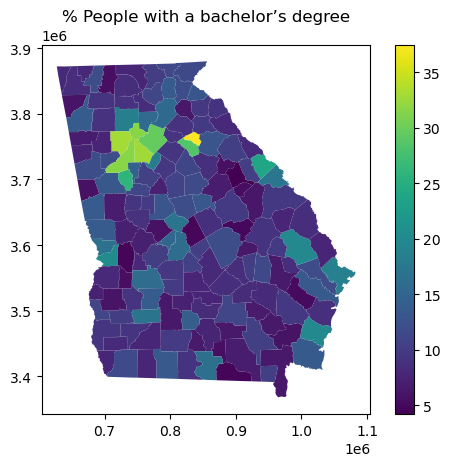

In [6]:
georgia_shp.plot(column="PctBach",legend=True)

plt.title("% People with a bachelor’s degree")

It can be seen that the Atlanta area and Athens have higher percentages of bachelor’s degrees, while more rural parts of Georgia have lower percentages.

### Model specification: 
PctBach = b0 + b1 * PctFB + b2 * PctBlack + b3 * PctRural
***
Prepare Georgia dataset to be input to `mgwr` library.

In [7]:
y = georgia_shp['PctBach'].values #the Y

var_names = ['PctFB', 'PctBlack', 'PctRural'] # variables used

X = georgia_shp[var_names].values #the Xs

u = georgia_shp['X']
v = georgia_shp['Y']

coords = list(zip(u,v)) #the coordinates

### Standardizing varaibles
- Standardize the data to have mean of 0 and variance of 1 sometimes is preferred to transform data on a common scale.

- The magnitudes of the coefficients are therefore comparable. Larger magnitude of the coefficient -> stronger relationship.

- If you calibrate an MGWR model, it is suggested to standardize the data beforehand. 

In [8]:
#Standardize variables (both X and Y)

X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean(axis=0)) / y.std(axis=0)

y = y.reshape(-1,1)

### Fit a GWR model in two steps
- Select the optimal bandwidths
- Use the optimal bandwidth to fit the GWR model
***
The default kernel is adaptive (# of nearest neighbors) bisquare.

In [9]:
gwr_selector = Sel_BW(coords, y, X)

gwr_bw = gwr_selector.search(verbose=True)

print("Selected optimal bandwidth is:", gwr_bw)

Bandwidth:  90.0 , score:  301.83
Bandwidth:  117.0 , score:  299.05
Bandwidth:  133.0 , score:  300.58
Bandwidth:  106.0 , score:  299.75
Bandwidth:  123.0 , score:  299.85
Bandwidth:  112.0 , score:  299.29
Bandwidth:  119.0 , score:  299.43
Bandwidth:  115.0 , score:  299.08
Selected optimal bandwidth is: 117.0


You can see from the bandwidth searching history, the algorithim tries many bandwidths and calculate AICc then use the optimal bandwidth with the minimum AICc as the final model.

In the best model with bandwidth=117, each local kernel has 117 counties.

Fit the model using the optimal bandwith

In [10]:
gwr_results = GWR(coords, y, X, gwr_bw, name_x=var_names).fit()

In [11]:
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 159
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             71.793
Log-likelihood:                                                    -162.399
AIC:                                                                332.798
AICc:                                                               335.191
BIC:                                                               -713.887
R2:                                                                   0.548
Adj. R2:                                                              0.540

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

The first half of the output "Global Regression Results" is for a typical linear regression model. 

The second half of the output is for the GWR results.

You can see the R2 value of the linear model = 0.548, and that of the GWR model = 0.678, which indicates a better model fit.

#### Viz

Write some mapping code to visualize the coefficient surfaces. We need to join the GWR result with the county GeoDataFrame.

This is pretty complicated code, but the final function `param_plots` can be reused with 
1. `result`: this should be the results you get from the GWR results
2. `gdf`: your GeoDataFrame
3. `names`: the names of the variables
4. `filter_sig`: whether the maps mask out non-significant coefficients.

In [12]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mgwr.utils import shift_colormap,truncate_colormap
from matplotlib import cm,colors


def param_plots(result, gdf, names=[], filter_sig=False):
    
    fig, axs = plt.subplots(2,2, figsize=(10, 10))
    axs = axs.ravel()
    
    k = gwr_results.k
    
    vmin = -0.8
    vmax = 0.8
    
    cmap = cm.get_cmap("coolwarm")
    norm = colors.BoundaryNorm(np.arange(-0.8,0.9,0.1),ncolors=256)
    
    if (vmin < 0) & (vmax < 0):
        cmap = truncate_colormap(cmap, 0.0, 0.5)
    elif (vmin > 0) & (vmax > 0):
        cmap = truncate_colormap(cmap, 0.5, 1.0)
    else:
        if 'shiftedcmap' not in plt.colormaps():
            cmap = shift_colormap(
            cm.get_cmap("coolwarm"),
            start=0.0,
            midpoint=1 - vmax / (vmax + abs(vmin)),
            stop=1.0
        )
        else:
            cmap = plt.get_cmap('shiftedcmap')
        #cmap = shift_colormap(cmap, start=0.0, midpoint=1 - vmax/(vmax + abs(vmin)), stop=1.)

    for j in range(k):
        
        pd.concat([gdf,pd.DataFrame(np.hstack([result.params,result.bse]))],axis=1).plot(ax=axs[j],column=j,vmin=vmin,vmax=vmax,
                                                                                         cmap="bwr",norm=norm,linewidth=0.1,edgecolor='white')
        axs[j].set_title("Coefficients of \n" + names[j],fontsize=10)
        
        if filter_sig:
            rslt_filtered_sig = result.filter_tvals()
            if (rslt_filtered_sig[:,j] == 0).any():
                gdf[rslt_filtered_sig[:,j] == 0].plot(color='lightgrey', ax=axs[j],linewidth=0.1,edgecolor='white')
        
        #plt.axis('off')
    
    fig = axs[j].get_figure()
    cax = fig.add_axes([0.99, 0.2, 0.025, 0.6])
    sm = plt.cm.ScalarMappable(cmap=cmap,norm=norm)
    
    
    sm._A = []
    fig.colorbar(sm, cax=cax)

#### Here are the maps of parameter estimates obtained from GWR. Each represent the spatial relationship between each predictor and PctBach.

- Positive (negative) relationships are shown in red (blue).
- Stronger (weaker) relationship has a darker (lighter) color.

/var/folders/mp/9px298sd6vs8xccb_3sql0dr0000gp/T/ipykernel_2023/2013949504.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm")
/var/folders/mp/9px298sd6vs8xccb_3sql0dr0000gp/T/ipykernel_2023/2013949504.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm.get_cmap("coolwarm"),


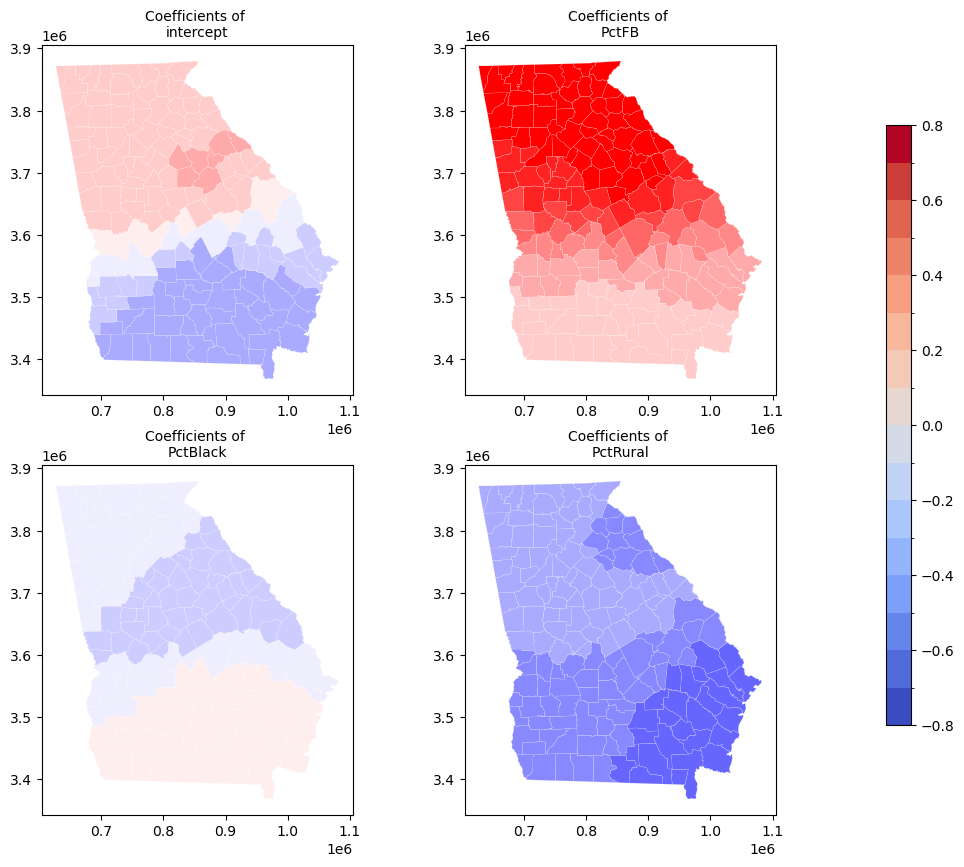

In [13]:
param_plots(gwr_results, georgia_shp,names=['intercept','PctFB', 'PctBlack', 'PctRural'])

#### Here are the maps of **SIGNIFICANT (p<0.05)** parameter estimates. 

Non-significant parameters are masked out in grey.


/var/folders/mp/9px298sd6vs8xccb_3sql0dr0000gp/T/ipykernel_2023/2013949504.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm")


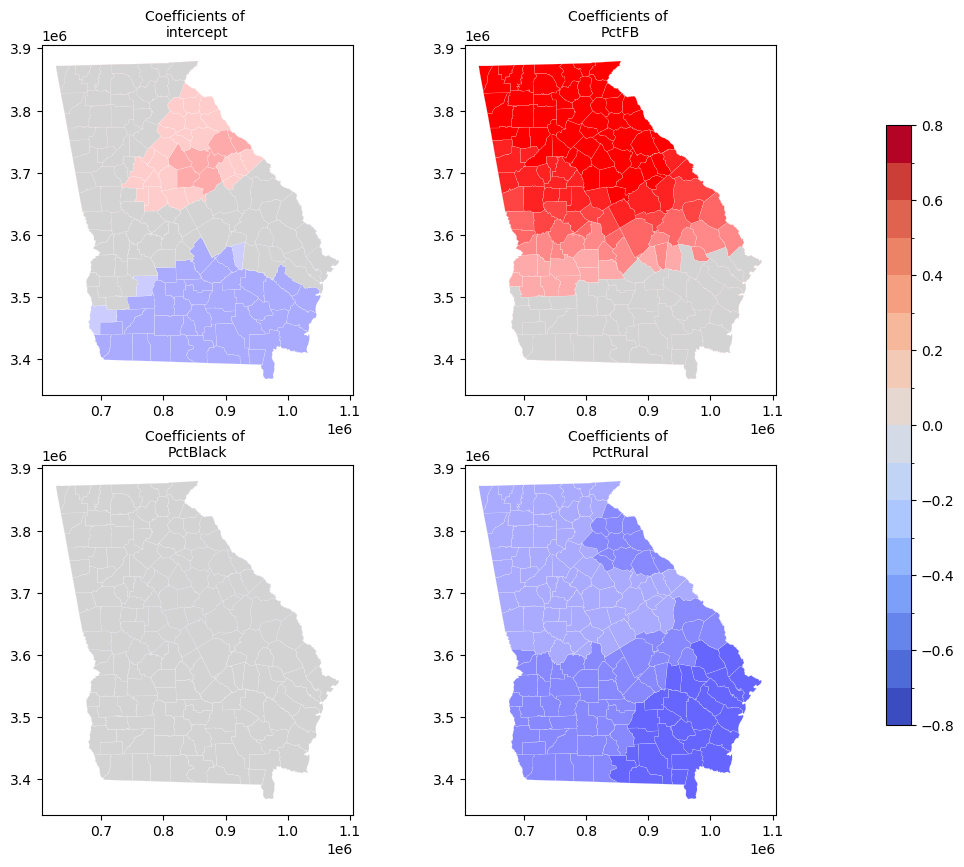

In [14]:
param_plots(gwr_results, georgia_shp,names=['intercept','PctFB', 'PctBlack', 'PctRural'], filter_sig=True)

You can see some of the coefficients are masked out in grey color that indicate they are not statistically significant.

## Fit the MGWR model

Similarly, we can fit an MGWR model

- Select the optimal bandwidths
- Fit the model

#### Note: MGWR can be very slow, if you have data with more than 2000 observations, then it may take a while to complete (from a few minutes to a few hours)

In [15]:
mgwr_selector = Sel_BW(coords, y, X, multi=True)
mgwr_bw = mgwr_selector.search()
print(mgwr_bw)

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

[101. 101. 117. 157.]


Pass the selector `mgwr_selector` to `MGWR()`

In [16]:
mgwr_results = MGWR(coords, y, X, mgwr_selector, name_x=var_names).fit()

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
mgwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 159
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             71.793
Log-likelihood:                                                    -162.399
AIC:                                                                332.798
AICc:                                                               335.191
BIC:                                                               -713.887
R2:                                                                   0.548
Adj. R2:                                                              0.540

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

You can see different variables may have different optimal bandwidths to capture relationships that operate at different level of spatial variation.

#### Model comparison
Based on both AICc (corrected Akaike Information Criterion, the lower the better) and R2 (the higher the better), we can see that both MGWR and GWR outperform OLS by allowing parameters to vary spatially. 

In this particular example, We don't see a big differece between GWR and MGWR because the bandwidths obtained in MGWR are similar to the single bandwidth from GWR. However, in some other cases the difference can be more noticable.


|      | OLS   | GWR   | MGWR |   |
|------|-------|-------|------|---|
| AICc | 335.2   | 299.1   | 297.0  |   |
| R2   | 0.548 | 0.678 | 0.680 |   |